In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string

import re
import nltk
import pymorphy3



In [2]:
df = pd.read_csv('total_500_movies.csv')

In [3]:
df.head()

,title,genre,year,country,rating,description
0,Ограбление в Лос-Анджелесе,"криминал, драма, триллер",2026,"США , Великобритания",6.7,Дерзкие ограбления неуловимого вора Дэвиса вдо...
1,"Удачи, веселья, не сдохни","боевик, драма, комедия, фантастика",2025,"США , Германия",7.0,Одним вечером в обычной закусочной появляется ...
2,Острые козырьки: Бессмертный человек,"история, драма, криминал",2026,"США , Франция , Великобритания",6.7,"1940-е годы, разгар Второй мировой войны. Спус..."
3,Чебурашка 2,"фэнтези, комедия, семейный",2025,Россия,7.6,"Уже год, как Чебурашка живет у Гены. Ушастик в..."
4,Король и Шут. Навсегда,"музыка, приключения, драма, комедия, фэнтези",2026,Россия,6.4,Панк-вселенной «Короля и Шута» грозит гибель. ...


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   title        500 non-null    object 
 1   genre        500 non-null    object 
 2   year         500 non-null    int64  
 3   country      500 non-null    object 
 4   rating       500 non-null    float64
 5   description  500 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 23.6+ KB


In [5]:
df['description'][0]

'Дерзкие ограбления неуловимого вора Дэвиса вдоль знаменитого шоссе 101 поставили полицию в тупик. Планируя последнее дело, которое должно стать «ударом всей жизни», он сталкивается с разочаровавшимся страховым брокером Шэрон, переживающей собственный переломный момент. Неожиданное сотрудничество между ними привлекает внимание настойчивого детектива Лу, который стремится раскрыть дело любой ценой, повышая ставки до предела.'

In [6]:
df['description'][200]

'Король Гарольд внезапно умер, и теперь великан Шрек вынужден стать королем Далекой-Далекой страны. Шрек уважает семейные традиции своей жены Фионы, но править страной очень не хочет, и поэтому и отправляется с Ослом и Котом в сапогах на поиски нового короля. Но пока Шрек ищет короля Артура - другого наследника, принц Чарминг замышляет новые пакости.'

In [7]:
# формирование корпуса
df['corpus'] = (df['title'].fillna('') + ' ' + 
                df['description'].fillna(''))

### Предобработка текста

In [8]:
st = '\xa0—'
def remove_othersymbol(text):
    return ''.join([ch if ch not in st else ' ' for ch in text])

In [9]:
df['prep_text']= [remove_othersymbol(text.lower()) for text in df['corpus']]

In [10]:
df['prep_text'][0]

'ограбление в лос-анджелесе дерзкие ограбления неуловимого вора дэвиса вдоль знаменитого шоссе 101 поставили полицию в тупик. планируя последнее дело, которое должно стать «ударом всей жизни», он сталкивается с разочаровавшимся страховым брокером шэрон, переживающей собственный переломный момент. неожиданное сотрудничество между ними привлекает внимание настойчивого детектива лу, который стремится раскрыть дело любой ценой, повышая ставки до предела.'

In [11]:
df['prep_text'][200]

'шрэк третий король гарольд внезапно умер, и теперь великан шрек вынужден стать королем далекой-далекой страны. шрек уважает семейные традиции своей жены фионы, но править страной очень не хочет, и поэтому и отправляется с ослом и котом в сапогах на поиски нового короля. но пока шрек ищет короля артура - другого наследника, принц чарминг замышляет новые пакости.'

In [12]:
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [13]:
def remove_punctuation(text):
    return ''.join([ch for ch in text if ch not in string.punctuation])

In [14]:
df['prep_text']= [remove_punctuation(text) for text in df['prep_text']]

In [15]:
df['prep_text'][0]

'ограбление в лосанджелесе дерзкие ограбления неуловимого вора дэвиса вдоль знаменитого шоссе 101 поставили полицию в тупик планируя последнее дело которое должно стать «ударом всей жизни» он сталкивается с разочаровавшимся страховым брокером шэрон переживающей собственный переломный момент неожиданное сотрудничество между ними привлекает внимание настойчивого детектива лу который стремится раскрыть дело любой ценой повышая ставки до предела'

In [16]:
df['prep_text'][200]

'шрэк третий король гарольд внезапно умер и теперь великан шрек вынужден стать королем далекойдалекой страны шрек уважает семейные традиции своей жены фионы но править страной очень не хочет и поэтому и отправляется с ослом и котом в сапогах на поиски нового короля но пока шрек ищет короля артура  другого наследника принц чарминг замышляет новые пакости'

In [17]:
df.head()

,title,genre,year,country,rating,description,corpus,prep_text
0,Ограбление в Лос-Анджелесе,"криминал, драма, триллер",2026,"США , Великобритания",6.7,Дерзкие ограбления неуловимого вора Дэвиса вдо...,Ограбление в Лос-Анджелесе Дерзкие ограбления ...,ограбление в лосанджелесе дерзкие ограбления н...
1,"Удачи, веселья, не сдохни","боевик, драма, комедия, фантастика",2025,"США , Германия",7.0,Одним вечером в обычной закусочной появляется ...,"Удачи, веселья, не сдохни Одним вечером в обыч...",удачи веселья не сдохни одним вечером в обычно...
2,Острые козырьки: Бессмертный человек,"история, драма, криминал",2026,"США , Франция , Великобритания",6.7,"1940-е годы, разгар Второй мировой войны. Спус...",Острые козырьки: Бессмертный человек 1940-е го...,острые козырьки бессмертный человек 1940е годы...
3,Чебурашка 2,"фэнтези, комедия, семейный",2025,Россия,7.6,"Уже год, как Чебурашка живет у Гены. Ушастик в...","Чебурашка 2 Уже год, как Чебурашка живет у Ген...",чебурашка 2 уже год как чебурашка живет у гены...
4,Король и Шут. Навсегда,"музыка, приключения, драма, комедия, фэнтези",2026,Россия,6.4,Панк-вселенной «Короля и Шута» грозит гибель. ...,Король и Шут. Навсегда Панк-вселенной «Короля ...,король и шут навсегда панквселенной «короля и ...


In [18]:
russian_stopwords = stopwords.words("russian") 

In [19]:
russian_stopwords.extend(['т.д.', 'т', 'д', 'это','который','свой','своём','всем','всё','её','оба','ещё','должный','фильм', 'кино', 'смотреть', 'год', 'снят', 'рассказывает', 'история', 
               'оказывается', 'вдруг', 'наконец', 'также', 'который', 'который', 'этот', 'эта', 'это', 'эти']) 

In [20]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\rafael\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [21]:
morph = pymorphy3.MorphAnalyzer(lang='ru')

In [22]:
%%time
lemm_texts_list = []
for text in (df['prep_text']):
    try:
        tokens = word_tokenize(text)
        res = list()
        for word in tokens:
            p = morph.parse(word)[0]
            res.append(p.normal_form)
        text = " ".join(res)
        lemm_texts_list.append(text)
    except Exception as e:
        print(e)
    
df['text_lemm'] = lemm_texts_list

CPU times: total: 7.8 s
Wall time: 8.23 s


In [23]:
df.head()

,title,genre,year,country,rating,description,corpus,prep_text,text_lemm
0,Ограбление в Лос-Анджелесе,"криминал, драма, триллер",2026,"США , Великобритания",6.7,Дерзкие ограбления неуловимого вора Дэвиса вдо...,Ограбление в Лос-Анджелесе Дерзкие ограбления ...,ограбление в лосанджелесе дерзкие ограбления н...,ограбление в лосанджелес дерзкий ограбление не...
1,"Удачи, веселья, не сдохни","боевик, драма, комедия, фантастика",2025,"США , Германия",7.0,Одним вечером в обычной закусочной появляется ...,"Удачи, веселья, не сдохни Одним вечером в обыч...",удачи веселья не сдохни одним вечером в обычно...,удача веселие не сдохнуть один вечером в обычн...
2,Острые козырьки: Бессмертный человек,"история, драма, криминал",2026,"США , Франция , Великобритания",6.7,"1940-е годы, разгар Второй мировой войны. Спус...",Острые козырьки: Бессмертный человек 1940-е го...,острые козырьки бессмертный человек 1940е годы...,острый козырёк бессмертный человек 1940 год ра...
3,Чебурашка 2,"фэнтези, комедия, семейный",2025,Россия,7.6,"Уже год, как Чебурашка живет у Гены. Ушастик в...","Чебурашка 2 Уже год, как Чебурашка живет у Ген...",чебурашка 2 уже год как чебурашка живет у гены...,чебурашка 2 уже год как чебурашка жить у ген у...
4,Король и Шут. Навсегда,"музыка, приключения, драма, комедия, фэнтези",2026,Россия,6.4,Панк-вселенной «Короля и Шута» грозит гибель. ...,Король и Шут. Навсегда Панк-вселенной «Короля ...,король и шут навсегда панквселенной «короля и ...,король и шут навсегда панквселенная « король и...


In [24]:
df['text_lemm'][0]

'ограбление в лосанджелес дерзкий ограбление неуловимый вор дэвис вдоль знаменитый шоссе 101 поставить полиция в тупик планировать последний дело который должный стать « удар весь жизнь » он сталкиваться с разочароваться страховой брокер шэрон переживать собственный переломный момент неожиданный сотрудничество между они привлекать внимание настойчивый детектив лу который стремиться раскрыть дело любой цена повышать ставка до предел'

In [25]:
df['text_lemm'][200]

'шрэк третий король гарольд внезапно умереть и теперь великан шрека вынудить стать король далекойдалека страна шрека уважать семейный традиция свой жена фиона но править страна очень не хотеть и поэтому и отправляться с осёл и кот в сапог на поиск новый король но пока шрека искать король артур другой наследник принц чарминг замышлять новый пакость'

In [26]:
def tokenize(text):
    t = word_tokenize(text)
    tokens = [token for token in t if token not in russian_stopwords and len(t) > 2]
    text = " ".join(tokens)
    return text

In [27]:
df['tokenize_text'] = [tokenize(text) for text in df['text_lemm']]

In [28]:
df.head()

,title,genre,year,country,rating,description,corpus,prep_text,text_lemm,tokenize_text
0,Ограбление в Лос-Анджелесе,"криминал, драма, триллер",2026,"США , Великобритания",6.7,Дерзкие ограбления неуловимого вора Дэвиса вдо...,Ограбление в Лос-Анджелесе Дерзкие ограбления ...,ограбление в лосанджелесе дерзкие ограбления н...,ограбление в лосанджелес дерзкий ограбление не...,ограбление лосанджелес дерзкий ограбление неул...
1,"Удачи, веселья, не сдохни","боевик, драма, комедия, фантастика",2025,"США , Германия",7.0,Одним вечером в обычной закусочной появляется ...,"Удачи, веселья, не сдохни Одним вечером в обыч...",удачи веселья не сдохни одним вечером в обычно...,удача веселие не сдохнуть один вечером в обычн...,удача веселие сдохнуть вечером обычный закусоч...
2,Острые козырьки: Бессмертный человек,"история, драма, криминал",2026,"США , Франция , Великобритания",6.7,"1940-е годы, разгар Второй мировой войны. Спус...",Острые козырьки: Бессмертный человек 1940-е го...,острые козырьки бессмертный человек 1940е годы...,острый козырёк бессмертный человек 1940 год ра...,острый козырёк бессмертный человек 1940 разгар...
3,Чебурашка 2,"фэнтези, комедия, семейный",2025,Россия,7.6,"Уже год, как Чебурашка живет у Гены. Ушастик в...","Чебурашка 2 Уже год, как Чебурашка живет у Ген...",чебурашка 2 уже год как чебурашка живет у гены...,чебурашка 2 уже год как чебурашка жить у ген у...,чебурашка 2 чебурашка жить ген ушастик взросле...
4,Король и Шут. Навсегда,"музыка, приключения, драма, комедия, фэнтези",2026,Россия,6.4,Панк-вселенной «Короля и Шута» грозит гибель. ...,Король и Шут. Навсегда Панк-вселенной «Короля ...,король и шут навсегда панквселенной «короля и ...,король и шут навсегда панквселенная « король и...,король шут навсегда панквселенная « король шут...


In [29]:
df['tokenize_text'][0]

'ограбление лосанджелес дерзкий ограбление неуловимый вор дэвис вдоль знаменитый шоссе 101 поставить полиция тупик планировать последний дело стать « удар весь жизнь » сталкиваться разочароваться страховой брокер шэрон переживать собственный переломный момент неожиданный сотрудничество привлекать внимание настойчивый детектив лу стремиться раскрыть дело любой цена повышать ставка предел'

In [30]:
df['tokenize_text'][200]

'шрэк третий король гарольд внезапно умереть великан шрека вынудить стать король далекойдалека страна шрека уважать семейный традиция жена фиона править страна очень хотеть поэтому отправляться осёл кот сапог поиск новый король пока шрека искать король артур наследник принц чарминг замышлять новый пакость'

In [31]:
pip install WordCloud

Note: you may need to restart the kernel to use updated packages.


In [32]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
%matplotlib inline

In [33]:
# Получение текстовой строки из списка слов
def str_corpus(corpus):
    str_corpus = ''
    for i in corpus:
        str_corpus += ' ' + i
    str_corpus = str_corpus.strip()
    return str_corpus

# Получение списка всех слов в корпусе
def get_corpus(data):
    corpus = []
    for phrase in data:
        for word in phrase.split():
            corpus.append(word)
    return corpus

# Получение облака слов
def get_wordCloud(corpus):
    wordCloud = WordCloud(background_color='white',
                              stopwords=STOPWORDS,
                              width=3000,
                              height=2500,
                              max_words=200,
                              random_state=42
                         ).generate(str_corpus(corpus))
    return wordCloud

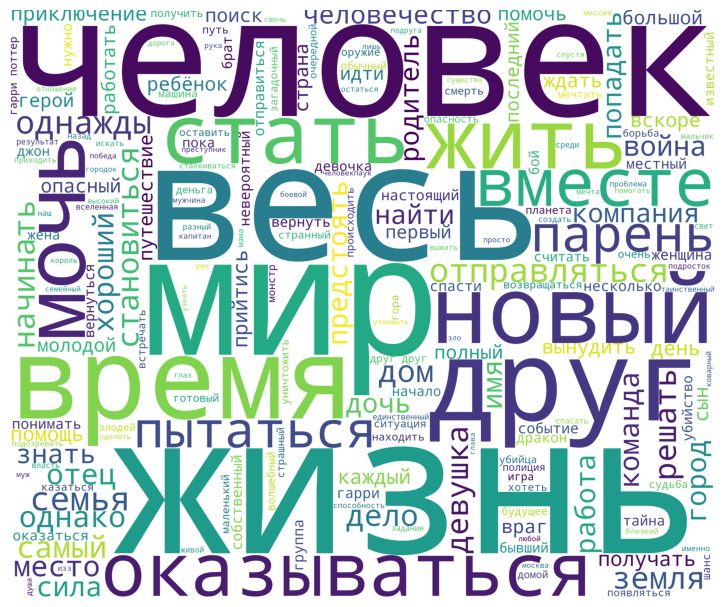

In [34]:
corpus = get_corpus(df['tokenize_text'].values)
procWordCloud = get_wordCloud(corpus)

fig = plt.figure(figsize=(20, 8))
plt.subplot(1, 2, 1)
plt.imshow(procWordCloud)
plt.axis('off')
plt.subplot(1, 2, 1)
plt.show()

In [35]:
# Получение облака слов
def get_wordCloud2(corpus):
    wordCloud = WordCloud(background_color='white',
                              stopwords=STOPWORDS,
                              width=3000,
                              height=2500,
                              max_words=200,
                              random_state=42
                         ).generate(corpus)
    return wordCloud

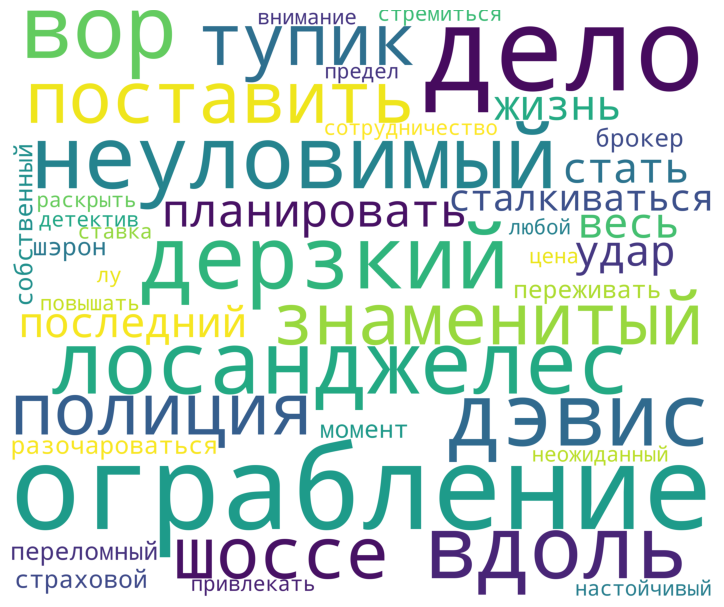

In [36]:
corpus = df['tokenize_text'][0]
procWordCloud = get_wordCloud2(corpus)

fig = plt.figure(figsize=(20, 8))
plt.subplot(1, 2, 1)
plt.imshow(procWordCloud)
plt.axis('off')
plt.subplot(1, 2, 1)
plt.show()

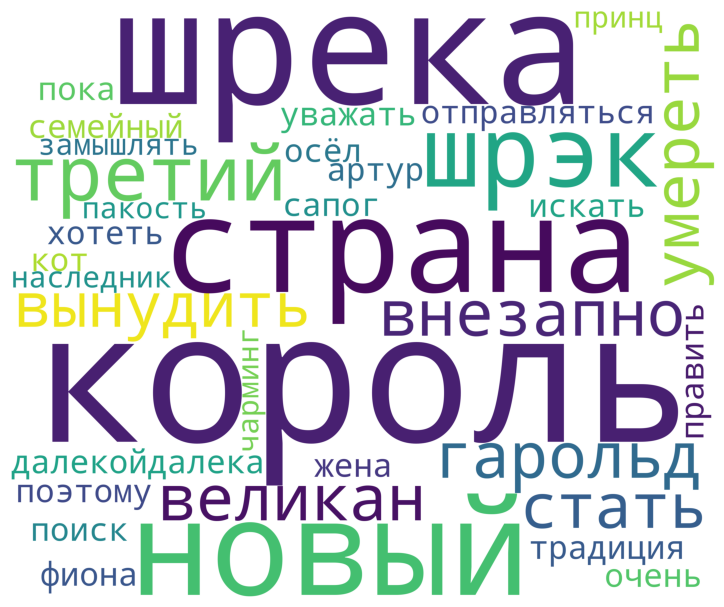

In [37]:
corpus = df['tokenize_text'][200]
procWordCloud = get_wordCloud2(corpus)

fig = plt.figure(figsize=(20, 8))
plt.subplot(1, 2, 1)
plt.imshow(procWordCloud)
plt.axis('off')
plt.subplot(1, 2, 1)
plt.show()

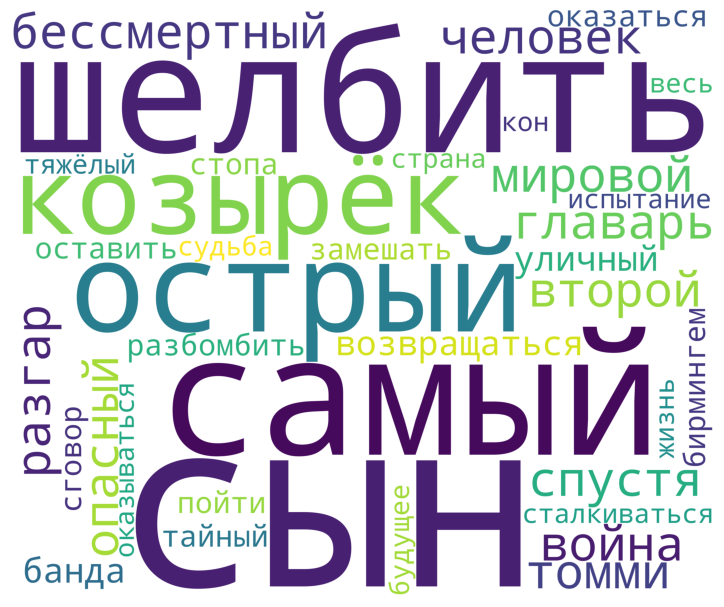

In [38]:
corpus = df['tokenize_text'][2]
procWordCloud = get_wordCloud2(corpus)

fig = plt.figure(figsize=(20, 8))
plt.subplot(1, 2, 1)
plt.imshow(procWordCloud)
plt.axis('off')
plt.subplot(1, 2, 1)
plt.show()

In [39]:
df.head()

,title,genre,year,country,rating,description,corpus,prep_text,text_lemm,tokenize_text
0,Ограбление в Лос-Анджелесе,"криминал, драма, триллер",2026,"США , Великобритания",6.7,Дерзкие ограбления неуловимого вора Дэвиса вдо...,Ограбление в Лос-Анджелесе Дерзкие ограбления ...,ограбление в лосанджелесе дерзкие ограбления н...,ограбление в лосанджелес дерзкий ограбление не...,ограбление лосанджелес дерзкий ограбление неул...
1,"Удачи, веселья, не сдохни","боевик, драма, комедия, фантастика",2025,"США , Германия",7.0,Одним вечером в обычной закусочной появляется ...,"Удачи, веселья, не сдохни Одним вечером в обыч...",удачи веселья не сдохни одним вечером в обычно...,удача веселие не сдохнуть один вечером в обычн...,удача веселие сдохнуть вечером обычный закусоч...
2,Острые козырьки: Бессмертный человек,"история, драма, криминал",2026,"США , Франция , Великобритания",6.7,"1940-е годы, разгар Второй мировой войны. Спус...",Острые козырьки: Бессмертный человек 1940-е го...,острые козырьки бессмертный человек 1940е годы...,острый козырёк бессмертный человек 1940 год ра...,острый козырёк бессмертный человек 1940 разгар...
3,Чебурашка 2,"фэнтези, комедия, семейный",2025,Россия,7.6,"Уже год, как Чебурашка живет у Гены. Ушастик в...","Чебурашка 2 Уже год, как Чебурашка живет у Ген...",чебурашка 2 уже год как чебурашка живет у гены...,чебурашка 2 уже год как чебурашка жить у ген у...,чебурашка 2 чебурашка жить ген ушастик взросле...
4,Король и Шут. Навсегда,"музыка, приключения, драма, комедия, фэнтези",2026,Россия,6.4,Панк-вселенной «Короля и Шута» грозит гибель. ...,Король и Шут. Навсегда Панк-вселенной «Короля ...,король и шут навсегда панквселенной «короля и ...,король и шут навсегда панквселенная « король и...,король шут навсегда панквселенная « король шут...


# Векторизация текстовых данных

### Bag of words

In [40]:
# CountVectorizer для LDA (LDA лучше работает с частотами)
count_vec = CountVectorizer(max_df=0.7, min_df=3, max_features=5000, ngram_range=(1, 3), analyzer='word')
count_matrix = count_vec.fit_transform(df['tokenize_text'])

feature_names = count_vec.get_feature_names_out()

In [41]:
len(count_vec.vocabulary_)

2015

In [42]:
count_matrix.shape

(500, 2015)

In [43]:
feature_names

array(['10', '10 спустя', '11летний', ..., 'язык', 'яйцо', 'япония'],
      dtype=object)

### TF-IDF

TF (Term Frequency) — __Частота термина__
Показывает, как часто слово встречается в конкретном документе.

IDF (Inverse Document Frequency) — __Обратная частота документа__
Показывает, насколько слово редкое или уникальное во всем корпусе. Чем чаще слово встречается в разных документах, тем менее оно важно

Объединяет TF и IDF, чтобы оценить уникальную важность слова в документе на фоне всего корпуса.

In [44]:
tfidf_vectorizer = TfidfVectorizer(
    max_df=0.7,          # игнорировать слова, встречающиеся в >70% документов
    min_df=3,            # игнорировать слова, встречающиеся менее чем в 3 документах
    max_features=5000,   # ограничить размер словаря
    ngram_range=(1, 3),  
    analyzer='word'
)

In [45]:
tfidf_matrix = tfidf_vectorizer.fit_transform(df['tokenize_text'])

In [46]:
tfidf_matrix.shape

(500, 2015)

In [47]:
print(tfidf_matrix)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 14537 stored elements and shape (500, 2015)>
  Coords	Values
  (0, 1029)	0.31763143526340665
  (0, 753)	0.17334590501522984
  (0, 378)	0.16770942431714708
  (0, 216)	0.16770942431714708
  (0, 551)	0.15517444877291958
  (0, 1263)	0.17334590501522984
  (0, 1225)	0.1304885405558873
  (0, 1167)	0.16770942431714708
  (0, 1258)	0.12008648333069864
  (0, 367)	0.2181197166524321
  (0, 1703)	0.09601387852643543
  (0, 1827)	0.16294384779004117
  (0, 142)	0.08231841619496963
  (0, 476)	0.07561579351568658
  (0, 1685)	0.13207427550045692
  (0, 1718)	0.18024439986137458
  (0, 101)	0.18024439986137458
  (0, 1145)	0.17334590501522984
  (0, 1608)	0.12359004570974257
  (0, 840)	0.14151516556036992
  (0, 951)	0.15881571763170332
  (0, 1643)	0.18024439986137458
  (0, 1326)	0.15881571763170332
  (0, 183)	0.16294384779004117
  (0, 899)	0.18024439986137458
  :	:
  (498, 322)	0.27004994194869447
  (498, 1084)	0.2612690521712379
  (498, 460)	0.2612

In [48]:
tfidf_vectorizer.get_feature_names_out()[150:160]

array(['весёлый', 'вечеринка', 'вечно', 'вечный', 'вечный проклятие',
       'вещь', 'взгляд', 'взрослый', 'взрыв', 'взять'], dtype=object)

# Тематическое моделирование

Тематическое моделирование позволяет выделять из текстов темы, связанные с определенными множествами слов, и затем смотреть, с какой вероятностью тексты соотносятся с этими темами. 

Библиотека **gensim**. Это популярная открытая библиотека для тематического моделирования, в которой есть нужная модель — LDA (Латентном размещении Дирихле (LDA)). Cледует создать словарь для тематического моделирования из лемматизированного текста. 

После создания словаря лучше всего отфильтровать те слова, которые встречаются в слишком большом количестве текстов, и те, которые встречаются слишком редко. Для этого есть метод filter_extremes, который принимает в себя аргументы no_above (только слова, которые встречаются не более чем в указанной доле текстов) и no_below (слова, которые встречаются не менее чем в указанном количестве текстов). 

После удаления лишних слов словарь лучше всего ужать в размерах, убрав пропуски.

In [49]:
import gensim

In [50]:
def tokenize2(text):
    t = word_tokenize(text)
    tokens = [token for token in t if token not in russian_stopwords]
    return tokens

In [51]:
df['tokenize_text3'] = [tokenize2(text) for text in df['tokenize_text']]

In [52]:
gensim_dictionary = gensim.corpora.Dictionary(df['tokenize_text3'])
gensim_dictionary.filter_extremes(no_above=0.1, no_below=20)
gensim_dictionary.compactify()

In [53]:
corpus = [gensim_dictionary.doc2bow(text) 
          for text in df['tokenize_text3']]

In [54]:
df.head()

,title,genre,year,country,rating,description,corpus,prep_text,text_lemm,tokenize_text,tokenize_text3
0,Ограбление в Лос-Анджелесе,"криминал, драма, триллер",2026,"США , Великобритания",6.7,Дерзкие ограбления неуловимого вора Дэвиса вдо...,Ограбление в Лос-Анджелесе Дерзкие ограбления ...,ограбление в лосанджелесе дерзкие ограбления н...,ограбление в лосанджелес дерзкий ограбление не...,ограбление лосанджелес дерзкий ограбление неул...,"[ограбление, лосанджелес, дерзкий, ограбление,..."
1,"Удачи, веселья, не сдохни","боевик, драма, комедия, фантастика",2025,"США , Германия",7.0,Одним вечером в обычной закусочной появляется ...,"Удачи, веселья, не сдохни Одним вечером в обыч...",удачи веселья не сдохни одним вечером в обычно...,удача веселие не сдохнуть один вечером в обычн...,удача веселие сдохнуть вечером обычный закусоч...,"[удача, веселие, сдохнуть, вечером, обычный, з..."
2,Острые козырьки: Бессмертный человек,"история, драма, криминал",2026,"США , Франция , Великобритания",6.7,"1940-е годы, разгар Второй мировой войны. Спус...",Острые козырьки: Бессмертный человек 1940-е го...,острые козырьки бессмертный человек 1940е годы...,острый козырёк бессмертный человек 1940 год ра...,острый козырёк бессмертный человек 1940 разгар...,"[острый, козырёк, бессмертный, человек, 1940, ..."
3,Чебурашка 2,"фэнтези, комедия, семейный",2025,Россия,7.6,"Уже год, как Чебурашка живет у Гены. Ушастик в...","Чебурашка 2 Уже год, как Чебурашка живет у Ген...",чебурашка 2 уже год как чебурашка живет у гены...,чебурашка 2 уже год как чебурашка жить у ген у...,чебурашка 2 чебурашка жить ген ушастик взросле...,"[чебурашка, 2, чебурашка, жить, ген, ушастик, ..."
4,Король и Шут. Навсегда,"музыка, приключения, драма, комедия, фэнтези",2026,Россия,6.4,Панк-вселенной «Короля и Шута» грозит гибель. ...,Король и Шут. Навсегда Панк-вселенной «Короля ...,король и шут навсегда панквселенной «короля и ...,король и шут навсегда панквселенная « король и...,король шут навсегда панквселенная « король шут...,"[король, шут, навсегда, панквселенная, «, коро..."


In [76]:
data_for_ml = df[['tokenize_text']]
data_for_ml.to_csv('movie_for_ml.csv',index=False,encoding='utf-8-sig')

In [55]:
corpus

[[(0, 2), (1, 1), (2, 1)],
 [(3, 1), (4, 1), (5, 1)],
 [(3, 1), (6, 1), (7, 1), (8, 1), (9, 1), (10, 2), (11, 1), (12, 1), (13, 3)],
 [(9, 1),
  (14, 1),
  (15, 1),
  (16, 1),
  (17, 1),
  (18, 1),
  (19, 1),
  (20, 1),
  (21, 1),
  (22, 1),
  (23, 1),
  (24, 1)],
 [],
 [(7, 1),
  (18, 1),
  (25, 1),
  (26, 2),
  (27, 1),
  (28, 1),
  (29, 1),
  (30, 1),
  (31, 1),
  (32, 1),
  (33, 1)],
 [(23, 1), (33, 1), (34, 1), (35, 1)],
 [(2, 1),
  (7, 1),
  (11, 1),
  (12, 1),
  (34, 1),
  (36, 1),
  (37, 1),
  (38, 1),
  (39, 1),
  (40, 1),
  (41, 1),
  (42, 1)],
 [(33, 1), (43, 1), (44, 1), (45, 1), (46, 1), (47, 1)],
 [(2, 1), (3, 1), (19, 1), (48, 1), (49, 1), (50, 1)],
 [(23, 1),
  (38, 1),
  (43, 1),
  (51, 1),
  (52, 1),
  (53, 1),
  (54, 2),
  (55, 1),
  (56, 1),
  (57, 1)],
 [(34, 1), (41, 1), (53, 1), (58, 1), (59, 1), (60, 1)],
 [(0, 1), (17, 1), (18, 2), (21, 1), (29, 1), (40, 1), (61, 1), (62, 1)],
 [(1, 1), (18, 1), (23, 1), (27, 1), (39, 1), (48, 1), (49, 1)],
 [(43, 1), (50, 1), 

In [56]:
lda_20 = gensim.models.LdaMulticore(corpus, 
                                 num_topics=7, 
                                 id2word=gensim_dictionary, 
                                 passes=10, random_state=6457)

In [57]:
lda_20.print_topics()

[(0,
  '0.046*"город" + 0.044*"спасти" + 0.042*"первый" + 0.035*"прийтись" + 0.034*"дом" + 0.032*"судьба" + 0.032*"сила" + 0.029*"получить" + 0.027*"поиск" + 0.026*"война"'),
 (1,
  '0.062*"парень" + 0.043*"становиться" + 0.042*"событие" + 0.039*"убийство" + 0.035*"каждый" + 0.034*"день" + 0.034*"работа" + 0.033*"очень" + 0.032*"молодой" + 0.030*"страшный"'),
 (2,
  '0.085*"самый" + 0.056*"однажды" + 0.048*"семья" + 0.046*"большой" + 0.045*"имя" + 0.036*"мечтать" + 0.028*"ребёнок" + 0.027*"страна" + 0.026*"получать" + 0.025*"знать"'),
 (3,
  '0.073*"команда" + 0.062*"хороший" + 0.047*"идти" + 0.043*"дело" + 0.034*"враг" + 0.029*"план" + 0.028*"опасный" + 0.027*"место" + 0.026*"семья" + 0.026*"каждый"'),
 (4,
  '0.070*"отец" + 0.053*"найти" + 0.052*"сын" + 0.033*"бывший" + 0.031*"дочь" + 0.030*"вернуть" + 0.028*"семья" + 0.026*"девушка" + 0.026*"попадать" + 0.025*"молодой"'),
 (5,
  '0.129*"земля" + 0.087*"человечество" + 0.056*"будущее" + 0.052*"невероятный" + 0.043*"помощь" + 0.040*"п

In [58]:
from sklearn.decomposition import LatentDirichletAllocation

In [59]:
n_topics = 7
n_top_words = 10

print("\n" + "="*60)
print("LDA (Латентное размещение Дирихле)")
print("="*60)
lda = LatentDirichletAllocation(n_components=n_topics, random_state=42, max_iter=100)
lda.fit(count_matrix)

def print_topics(model, feature_names, n_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print(f"Тема {topic_idx + 1}:")
        top_words_idx = topic.argsort()[:-n_top_words - 1:-1]
        top_words = [feature_names[i] for i in top_words_idx]
        print(" ".join(top_words))
        print()

print_topics(lda, feature_names, n_top_words)


LDA (Латентное размещение Дирихле)
Тема 1:
время оказываться друг чёрный снова пытаться земля приключение джек пират

Тема 2:
мир стать весь человек дело питер самый москва демон помощь

Тема 3:
человек время жизнь жить мир друг новый джон каждый самый

Тема 4:
друг жизнь оказываться человек весь отец семья вместе дом дочь

Тема 5:
гарри жизнь поттер гарри поттер отправляться волшебник хогвартс начинать питер попадать

Тема 6:
мир весь жизнь мочь друг решать команда джек элизабет капитан

Тема 7:
жизнь новый человек парень родитель друг мир решать кот время



In [60]:
import pyLDAvis.gensim_models as gensimvis
import pyLDAvis

In [61]:
vis_20 = gensimvis.prepare(lda_20, corpus, gensim_dictionary)

In [62]:
pyLDAvis.enable_notebook()

In [63]:
vis_20

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
6      0.084051 -0.050964       1        1  16.794575
3      0.033647  0.167456       2        1  15.448639
4     -0.003350 -0.131210       3        1  15.217278
1      0.031170 -0.122577       4        1  14.712725
0      0.026017  0.104483       5        1  13.724112
2      0.103644  0.022019       6        1  13.540239
5     -0.275179  0.010793       7        1  10.562432, topic_info=            Term       Freq      Total Category  logprob  loglift
58         земля  47.000000  47.000000  Default  30.0000  30.0000
82       команда  35.000000  35.000000  Default  29.0000  29.0000
5   человечество  34.000000  34.000000  Default  28.0000  28.0000
10         самый  53.000000  53.000000  Default  27.0000  27.0000
56          отец  39.000000  39.000000  Default  26.0000  26.0000
..           ...        ...        ...      ...      ...      ...
34    предстоять   4.845659  35.869108   Topic7  -4.1960   0.2461
70          план   2.478682  19.985836   Topic7  -4.8663   0.1606
6   возвращаться   2.983357  24.113899   Topic7  -4.6810   0.1581
74       большой   3.868193  31.800400   Topic7  -4.4213   0.1412
95      компания   3.445299  33.267433   Topic7  -4.5370  -0.0197

[265 rows x 6 columns], token_table=      Topic      Freq          Term
term                               
14        1  0.194067             2
14        2  0.271694             2
14        3  0.271694             2
14        4  0.077627             2
14        6  0.155254             2
...     ...       ...           ...
5         7  0.817163  человечество
47        1  0.436111         школа
47        3  0.218056         школа
47        4  0.261667         школа
47        5  0.043611         школа

[434 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[7, 4, 5, 2, 1, 3, 6])

LDA - это метод машинного обучения, который используется для анализа тематической структуры в больших наборах документов. Который использует модель вероятности, чтобы определить, какие темы присутствуют в каждом документе, и какие слова связаны с каждой темой. LDA может быть полезен в случаях, когда нужно опредлить тематическую структуру в большом наборе документов, таких как статьи и т.д.

In [64]:
from gensim.models import CoherenceModel

coherence_model = CoherenceModel(model=lda_20,
                                 texts=df['tokenize_text3'],
                                 dictionary=gensim_dictionary,
                                 coherence="c_v")

coherence_value = coherence_model.get_coherence()
print(f"Когерентность модели: {coherence_value}")

Когерентность модели: 0.2296789697166779


CoherenceModel — это класс из библиотеки Gensim, который используется для оценки качества тематической модели (например, LDA) с помощью метрики когерентности (coherence). Когерентность измеряет, насколько хорошо темы, выявленные моделью, соответствуют человеческому восприятию. Чем выше когерентность, тем более интерпретируемыми и осмысленными являются темы.

In [65]:
from sklearn.decomposition import LatentDirichletAllocation

In [66]:
# создание модели LDA
lda_model = LatentDirichletAllocation(n_components=7, random_state=0)
lda_model.fit(count_matrix)

# вывод топ слов для каждой темы
for i, topic in enumerate(lda_model.components_):
    print(f"Topic {i}: {', '.join([count_vec.get_feature_names_out()[i] for i in topic.argsort()[:-11:-1]])}")

Topic 0: мир, весь, человек, стать, жизнь, предстоять, новый, дракон, однажды, парень
Topic 1: кольцо, джек, весь, капитан, элизабет, пират, жизнь, друг, день, уничтожить
Topic 2: друг, питер, время, весь, новый, миссия, вирус, галактика, сила, лондон
Topic 3: человек, время, жить, мир, отправляться, семья, весь, жизнь, вместе, друг
Topic 4: друг, жизнь, гарри, человек, новый, джон, семья, парень, пытаться, мочь
Topic 5: жизнь, весь, становиться, мочь, мир, стать, отправляться, друг, время, девушка
Topic 6: жизнь, оказываться, отец, дом, новый, парень, цель, брат, волшебник, находить


In [67]:
lda_model = LatentDirichletAllocation(learning_method='online', random_state=5, n_jobs=-1, n_components=11)
lda_model.fit(tfidf_matrix)

LatentDirichletAllocation(learning_method='online', n_components=11, n_jobs=-1,
                          random_state=5)

In [68]:
#датафрейм для ключевых слов каждой темы
topic_keywords = pd.DataFrame()
for i,topic in enumerate(lda_model.components_):
    topic_keywords[f'Topic {i + 1}'] = [count_vec.get_feature_names_out()[i] for i in topic.argsort()[-10:]]
topic_keywords

,Topic 1,Topic 2,Topic 3,Topic 4,Topic 5,Topic 6,Topic 7,Topic 8,Topic 9,Topic 10,Topic 11
0,хороший,уничтожить,проникнуть,гарри поттер,дракон,ночь,паркер,ценный,поворачивать,знать,вскоре
1,человечество,саурон,лес,парень,война,период,решать,основной,лес,стать,питер
2,каждый,крепость,служить,комната,шерлок,грузовик,похищать,ресурс,бой,капитан,дом
3,джон,всевластие,бесконечность,титан,шерлок холмс,найти,жизнь,дюна,армия,море,друг друг
4,весь,кольцо всевластие,смочь,дядя,холмс,заболевание,полицейский,башня,временной петля,девушка,жизнь
5,земля,средиземье,реальность,богатырь,мировой,компания,дело,эпический,мочь,элизабет,папа
6,время,властелин,пёс,новый,мировой война,валерий,разный,атрейдес,советский,мир,мажор
7,мир,властелин кольцо,превращаться,князь,второй мировой война,древний,зверополис,вынудить бежать,снова,друг,новый
8,жизнь,братство,мститель,король,второй мировой,анна,весь,враждебный,умирать,гарри,парень
9,человек,кольцо,томас,гарри,второй,легенда,город,пол,петля,джек,друг


NMF - это метод машинного обучения, который используется для разложения матрицы на две с неотрицательными элементами. Он может быть полезен в случаях, когда нужно найти скрытые признаки в данных, таких как тексты и т.д. NMF может использоваться в различных областях, таких как обработка изображений, текстовый анализ и т.д

NMF (Non-negative Matrix Factorization) — метод разложения матрицы на две неотрицательные матрицы:

__Исходная матрица (документы × слова) ≈ Матрица тем (документы × темы) × Матрица слов (темы × слова)__

Матрица слов содержит "слова-темы" и показывает, какие слова характеризуют каждую тему.

Матрица тем содержит "темы-документы" и показывает, насколько каждая тема присутствует в каждом документе.

In [69]:
from sklearn.decomposition import NMF

In [70]:
# создание модели NMF
nmf_model = NMF(n_components=10, random_state=0)
nmf_model.fit(tfidf_matrix)

# вывод топ слов для каждой темы
for i, topic in enumerate(nmf_model.components_):
    print(f"Topic {i}: {', '.join([tfidf_vectorizer.get_feature_names_out()[i] for i in topic.argsort()[:-11:-1]])}")

Topic 0: жизнь, время, человек, джон, начинать, пытаться, убийца, мочь, решать, место
Topic 1: гарри, гарри поттер, поттер, хогвартс, волшебник, школа, чародейство волшебство, волшебство хогвартс, курс школа, школа чародейство
Topic 2: джек, элизабет, капитан, пират, уилла, море, карибский море, карибский, пират карибский, пират карибский море
Topic 3: земля, человечество, мститель, человек, путешествие, невероятный, будущее, новый, грань, планета
Topic 4: кольцо, средиземье, братство, властелин, властелин кольцо, бильбо, уничтожить, хоббит, саурон, кольцо всевластие
Topic 5: питер, человекпаук, паркер, питер паркер, супергерой, вселенная, вместе, измерение, спасать, разный
Topic 6: друг, друг друг, кот, новый, приключение, родитель, событие, новый друг, компот, жизнь
Topic 7: мир, хороший, парень, весь, дракон, город, герой, дело, команда, нужно
Topic 8: семья, стать, отправляться, мечтать, дочь, девушка, мама, жить, дом, оставить
Topic 9: мировой война, второй мировой, второй мировой

C:\Users\rafael\anaconda3\Lib\site-packages\sklearn\decomposition\_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


In [71]:
# создание модели NMF
nmf_model = NMF(n_components=7, random_state=0)
nmf_model.fit(tfidf_matrix)

# вывод топ слов для каждой темы
for i, topic in enumerate(nmf_model.components_):
    print(f"Topic {i}: {', '.join([tfidf_vectorizer.get_feature_names_out()[i] for i in topic.argsort()[:-11:-1]])}")

Topic 0: мир, семья, девушка, весь, стать, жизнь, жить, парень, однажды, становиться
Topic 1: гарри, поттер, гарри поттер, хогвартс, волшебник, школа, чародейство волшебство хогвартс, чародейство, волшебство хогвартс, школа чародейство
Topic 2: джек, элизабет, капитан, пират, уилла, море, карибский море, карибский, пират карибский море, пират карибский
Topic 3: человек, земля, человечество, время, война, будущее, сын, мочь, мститель, пытаться
Topic 4: кольцо, средиземье, братство, властелин кольцо, властелин, бильбо, хоббит, уничтожить, саурон, кольцо всевластие
Topic 5: питер, человекпаук, паркер, питер паркер, супергерой, вселенная, вместе, измерение, разный, спасать
Topic 6: друг, друг друг, новый, кот, родитель, жизнь, приключение, ждать, событие, компот


In [72]:
nmf_transformed = nmf_model.transform(tfidf_matrix)

print("\nТОП-3 ФИЛЬМА ДЛЯ КАЖДОЙ ТЕМЫ:\n")
for topic_idx in range(n_topics):
    topic_scores = nmf_transformed[:, topic_idx]
    top_docs_idx = np.argsort(topic_scores)[-5:][::-1]
    
    print(f" Topic {topic_idx}")
    for rank, doc_idx in enumerate(top_docs_idx[:3], 1):
        title = df.iloc[doc_idx]['title']
        rating = df.iloc[doc_idx]['rating']
        score = topic_scores[doc_idx]
        print(f"   {rank}. {title} (рейтинг: {rating}) — уверенность: {score:.3f}")
    print()


ТОП-3 ФИЛЬМА ДЛЯ КАЖДОЙ ТЕМЫ:

 Topic 0
   1. Главный герой (рейтинг: 7.4) — уверенность: 0.189
   2. Главный герой (рейтинг: 7.366) — уверенность: 0.189
   3. Шоу Трумана (рейтинг: 8.283) — уверенность: 0.148

 Topic 1
   1. Гарри Поттер и Тайная комната (рейтинг: 8.1) — уверенность: 0.518
   2. Гарри Поттер и Тайная комната (рейтинг: 8.152) — уверенность: 0.518
   3. Гарри Поттер и Кубок огня (рейтинг: 7.9) — уверенность: 0.517

 Topic 2
   1. Пираты Карибского моря: Сундук мертвеца (рейтинг: 8.0) — уверенность: 0.546
   2. Пираты Карибского моря: Сундук мертвеца (рейтинг: 8.15) — уверенность: 0.546
   3. Пираты Карибского моря: На краю света (рейтинг: 7.9) — уверенность: 0.524

 Topic 3
   1. Терминатор 2: Судный день (рейтинг: 8.42) — уверенность: 0.202
   2. Война будущего (рейтинг: 6.5) — уверенность: 0.193
   3. Мстители (рейтинг: 7.9) — уверенность: 0.190

 Topic 4
   1. Властелин колец: Братство кольца (рейтинг: 8.7) — уверенность: 0.490
   2. Властелин колец: Братство кольца

LSA - это метод машинного обучения, который используется для анализа структуры в больших наборах текстовых данных. Он использует матричные вычисления для определения близости между словами и документами. LSA может быть полезен в случаях, когда вы хотите определить структуру в большом наборе текстовых данных, таких как статьи, отчеты и т.д.

In [73]:
from sklearn.decomposition import TruncatedSVD

In [74]:
# создание модели LSA
lsa_model = TruncatedSVD(n_components=7, random_state=0)
lsa_model.fit(tfidf_matrix)

# вывод топ слов для каждой темы
for i, topic in enumerate(lsa_model.components_):
    print(f"Topic {i}: {', '.join([tfidf_vectorizer.get_feature_names_out()[i] for i in topic.argsort()[:-11:-1]])}")

Topic 0: друг, жизнь, человек, мир, время, весь, новый, мочь, стать, жить
Topic 1: гарри, поттер, гарри поттер, хогвартс, волшебник, школа, волшебство хогвартс, чародейство волшебство, чародейство волшебство хогвартс, чародейство
Topic 2: джек, элизабет, капитан, пират, уилла, море, карибский, карибский море, пират карибский, пират карибский море
Topic 3: кольцо, уничтожить, мститель, братство, средиземье, земля, человечество, властелин, властелин кольцо, армия
Topic 4: кольцо, друг, бильбо, средиземье, хоббит, властелин кольцо, властелин, братство, саурон, власть
Topic 5: человек, война, время, мировой, мировой война, второй мировой, второй мировой война, второй, будущее, человечество
Topic 6: друг, вместе, питер, отправляться, человечество, путешествие, земля, сын, друг друг, планета
